# Waste Classification — Data Preparation Notebook

Use this notebook to verify the dataset folders before training. The goal is to catch dproblems like duplicate folders name, or empty class folders before running the training scripts.

In [ ]:
from pathlib import Path
import os
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import random

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
CLASSES = ["cardboard", "plastic", "metal", "glass"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"}

print("Project root:", PROJECT_ROOT)
print("Data dir exists:", DATA_DIR.exists())
print("Raw dir exists:", RAW_DIR.exists())

## 1. Checking raw dataset structure

Expected raw folder structure:

```text
data/raw/cardboard
data/raw/plastic
data/raw/metal
data/raw/glass
```

In [ ]:
def count_images(folder: Path):
    if not folder.exists():
        return 0
    return sum(1 for p in folder.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS)

rows = []
for cls in CLASSES:
    class_dir = RAW_DIR / cls
    rows.append({
        "class": cls,
        "path": str(class_dir),
        "exists": class_dir.exists(),
        "num_images": count_images(class_dir)
    })

raw_counts = pd.DataFrame(rows)
raw_counts

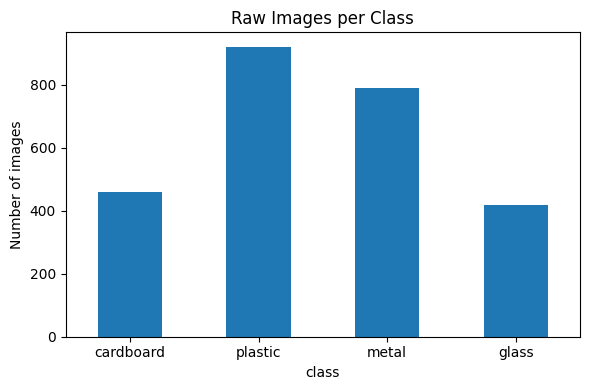

In [7]:
ax = raw_counts.plot(kind="bar", x="class", y="num_images", legend=False, figsize=(6,4))
ax.set_title("Raw Images per Class")
ax.set_ylabel("Number of images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Checking generated train/val/test folders

In [9]:
def split_summary():
    rows = []
    for split in ["train", "val", "test", "synthetic_train"]:
        split_dir = DATA_DIR / split
        if not split_dir.exists():
            rows.append({"split": split, "class": "<missing split>", "num_images": 0, "status": "missing"})
            continue
        subdirs = sorted([p for p in split_dir.iterdir() if p.is_dir()])
        for subdir in subdirs:
            status = "good" if subdir.name in CLASSES else "unexpected class folder"
            rows.append({"split": split, "class": subdir.name, "num_images": count_images(subdir), "status": status})
    return pd.DataFrame(rows)

summary = split_summary()
summary

,split,class,num_images,status
0,train,cardboard,70,good
1,train,glass,70,good
2,train,metal,70,good
3,train,plastic,70,good
4,val,cardboard,15,good
5,val,glass,15,good
6,val,metal,15,good
7,val,plastic,15,good
8,test,cardboard,15,good
9,test,glass,15,good


In [10]:
if not summary.empty:
    pivot = summary.pivot_table(index="class", columns="split", values="num_images", aggfunc="sum", fill_value=0)
    display(pivot)

split,synthetic_train,test,train,val
class,,,,
cardboard,70,15,70,15
glass,70,15,70,15
metal,70,15,70,15
plastic,70,15,70,15


## 3. Visualize sample images

Verify labels visually before training.

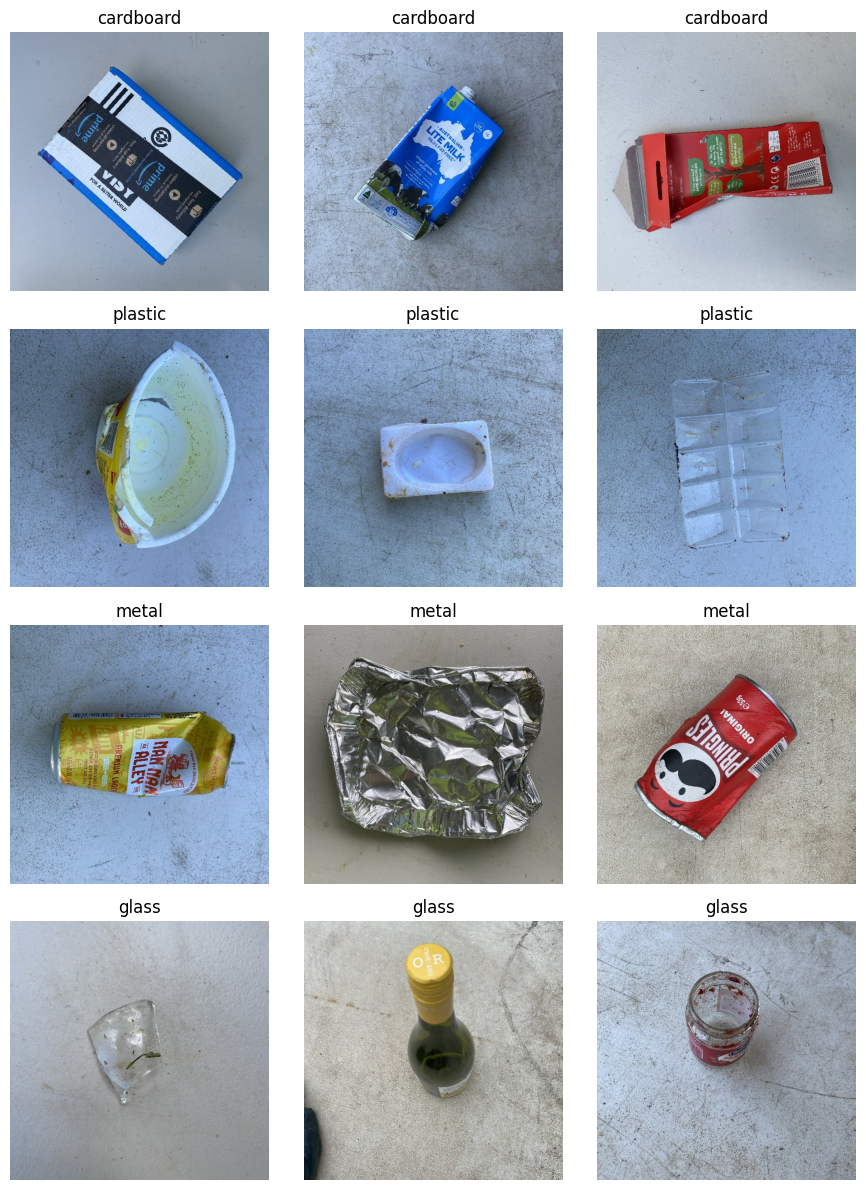

In [11]:
def sample_images(split="train", n_per_class=3):
    fig, axes = plt.subplots(len(CLASSES), n_per_class, figsize=(3*n_per_class, 3*len(CLASSES)))
    if len(CLASSES) == 1:
        axes = [axes]

    for row, cls in enumerate(CLASSES):
        class_dir = DATA_DIR / split / cls
        images = [p for p in class_dir.glob("*") if p.suffix.lower() in IMAGE_EXTENSIONS] if class_dir.exists() else []
        chosen = random.sample(images, min(n_per_class, len(images))) if images else []
        for col in range(n_per_class):
            ax = axes[row][col]
            ax.axis("off")
            if col < len(chosen):
                img = Image.open(chosen[col]).convert("RGB")
                ax.imshow(img)
                ax.set_title(cls)
            else:
                ax.set_title(f"{cls}: missing")
    plt.tight_layout()
    plt.show()

sample_images("train", n_per_class=3)

## 4. Commands to rebuild generated data 

Run these in terminal from the project root. This keeps `data/raw` safe:

```bash
rm -rf data/train data/val data/test data/synthetic_train
rm -rf results
python -m src.prepare_data
python -m src.create_synthetic_data
```